# 03 — Evaluate the trained DeLaN

In [1]:
import sys, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if ROOT not in sys.path: sys.path.insert(0, ROOT)
import numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from training_v2.data import load_split, DoublePendulumDataset
from training_v2.model import DeepLagrangianNetwork_f1, DeepLagrangianNetwork_f2
from training_v2.evaluation import rollout, one_step_metrics, rollout_metrics, total_energy

FILTERED_DIR='../filtered'; CKPT_DIR='../checkpoints'
device='cpu'

In [2]:
train_p, val_p, test_p = load_split(os.path.join(CKPT_DIR, 'split.json'))
print(f'test files ({len(test_p)}):')
for p in test_p: print(' -', os.path.basename(p))

test files (13):
 - 169_data16.csv
 - 169_data37.csv
 - 169_data38.csv
 - 169_data46.csv
 - 169_data54.csv
 - 169_data67.csv
 - 169_data79.csv
 - 169_data89.csv
 - 171_data36.csv
 - 171_data40.csv
 - 171_data48.csv
 - 171_data68.csv
 - 171_data77.csv


In [3]:
model = DeepLagrangianNetwork_f1(n_dof=2, learn_friction=True, n_width=64, n_depth=2,
                              activation='Sine',
                              diagonal_epsilon=1e-3, b_diag_init=0.5)
ck = torch.load(os.path.join(CKPT_DIR, 'delan_best91_sine_f1_1.pt'), map_location=device, weights_only=False)
model.load_state_dict(ck['model']); model.to(device).eval()
print(f"loaded best checkpoint from epoch {ck['epoch']}")

loaded best checkpoint from epoch 590


## Test 1 — One-step prediction

In [4]:
test_set = DoublePendulumDataset(test_p, stride=5, device=device)
m = one_step_metrics(model, test_set)
print(f"MAE  tau (Nm):       {m['mae_tau']:.4e}")
print(f"MAE  qdd (rad/s^2):  {m['mae_qdd']:.4e}")
print(f"per joint MAE tau:  shoulder={m['mae_tau_joint'][0]:.4e}, elbow={m['mae_tau_joint'][1]:.4e}")
print(f"per joint MAE qdd:  shoulder={m['mae_qdd_joint'][0]:.4e}, elbow={m['mae_qdd_joint'][1]:.4e}")

MAE  tau (Nm):       4.9349e-03
MAE  qdd (rad/s^2):  4.9031e+00
per joint MAE tau:  shoulder=4.5895e-03, elbow=5.2804e-03
per joint MAE qdd:  shoulder=4.5895e+00, elbow=5.2167e+00


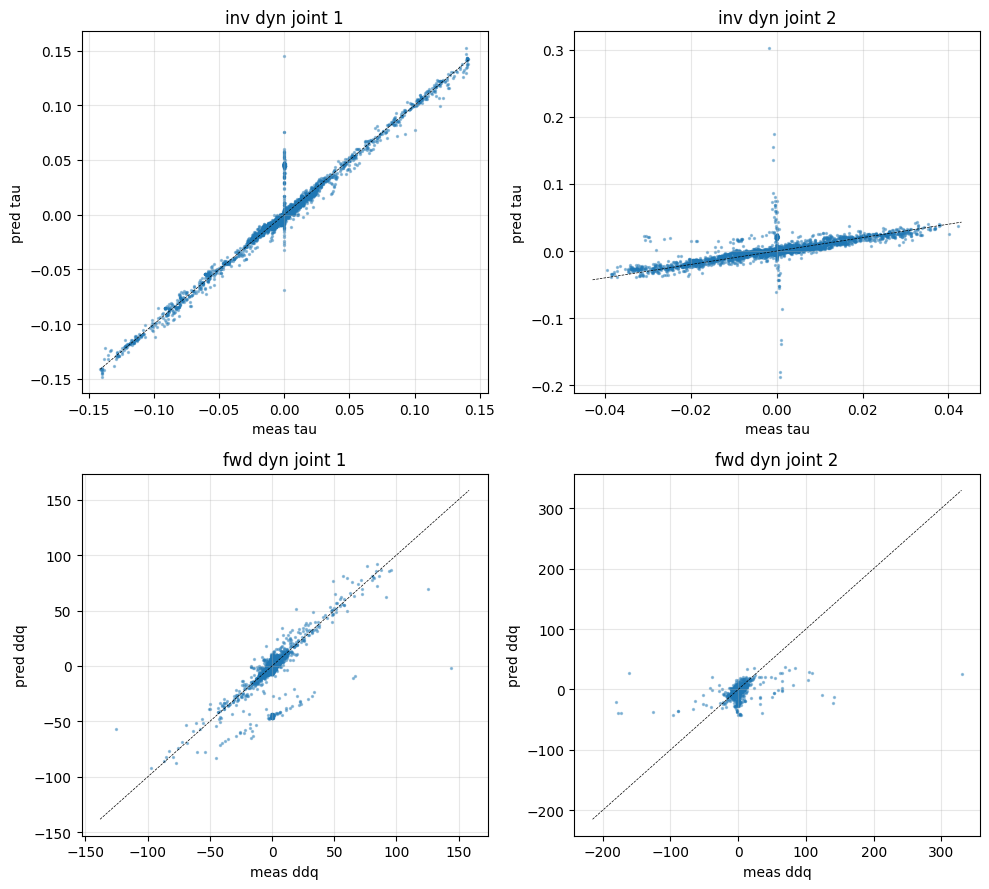

In [5]:
rng = np.random.default_rng(0)
idx = rng.choice(len(m['tau']), min(3000, len(m['tau'])), replace=False)
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for j, nm in enumerate(['1','2']):
    axes[0,j].scatter(m['tau'][idx,j], m['tau_pred'][idx,j], s=2, alpha=.4)
    lo, hi = m['tau'][:,j].min(), m['tau'][:,j].max()
    axes[0,j].plot([lo,hi],[lo,hi],'k--',lw=.5); axes[0,j].set_title(f'inv dyn joint {nm}')
    axes[0,j].set_xlabel('meas tau'); axes[0,j].set_ylabel('pred tau'); axes[0,j].grid(True, alpha=.3)
    axes[1,j].scatter(m['qdd'][idx,j], m['qdd_pred'][idx,j], s=2, alpha=.4)
    lo, hi = m['qdd'][:,j].min(), m['qdd'][:,j].max()
    axes[1,j].plot([lo,hi],[lo,hi],'k--',lw=.5); axes[1,j].set_title(f'fwd dyn joint {nm}')
    axes[1,j].set_xlabel('meas ddq'); axes[1,j].set_ylabel('pred ddq'); axes[1,j].grid(True, alpha=.3)
plt.tight_layout(); plt.show()

## Test 2 — Rollout

In [6]:
ROLLOUT_HORIZON_S = 8.0; DIVERGENCE_THRESH = 0.087
results = []
for path in test_p:
    df = pd.read_csv(path)
    t_meas = df['time'].to_numpy()
    X_meas = df[['pos1','pos2','vel1','vel2']].to_numpy()
    tau    = df[['tau1','tau2']].to_numpy()
    dt = float(t_meas[1] - t_meas[0])
    N = min(len(tau), int(ROLLOUT_HORIZON_S / dt))
    t_pred, X_pred = rollout(model, X_meas[0], dt, tau[:N], integrator='rk4')
    rm = rollout_metrics(t_pred, X_pred, X_meas[:N+1], divergence_thresh=DIVERGENCE_THRESH)
    rm.update(path=path, t_pred=t_pred, X_pred=X_pred, X_meas=X_meas[:N+1])
    results.append(rm)
    print(f"{os.path.basename(path):30s}  ttd={rm['time_to_divergence']:5.2f}s")
ttd = [r['time_to_divergence'] for r in results]
print(f"\nmedian time-to-divergence: {np.median(ttd):.2f}s")

169_data16.csv                  ttd= 0.15s
169_data37.csv                  ttd= 4.68s
169_data38.csv                  ttd= 4.65s
169_data46.csv                  ttd= 0.22s
169_data54.csv                  ttd= 0.20s
169_data67.csv                  ttd= 0.65s
169_data79.csv                  ttd= 0.02s
169_data89.csv                  ttd= 0.04s
171_data36.csv                  ttd= 4.39s
171_data40.csv                  ttd= 4.43s
171_data48.csv                  ttd= 0.98s
171_data68.csv                  ttd= 0.24s
171_data77.csv                  ttd= 0.20s

median time-to-divergence: 0.24s


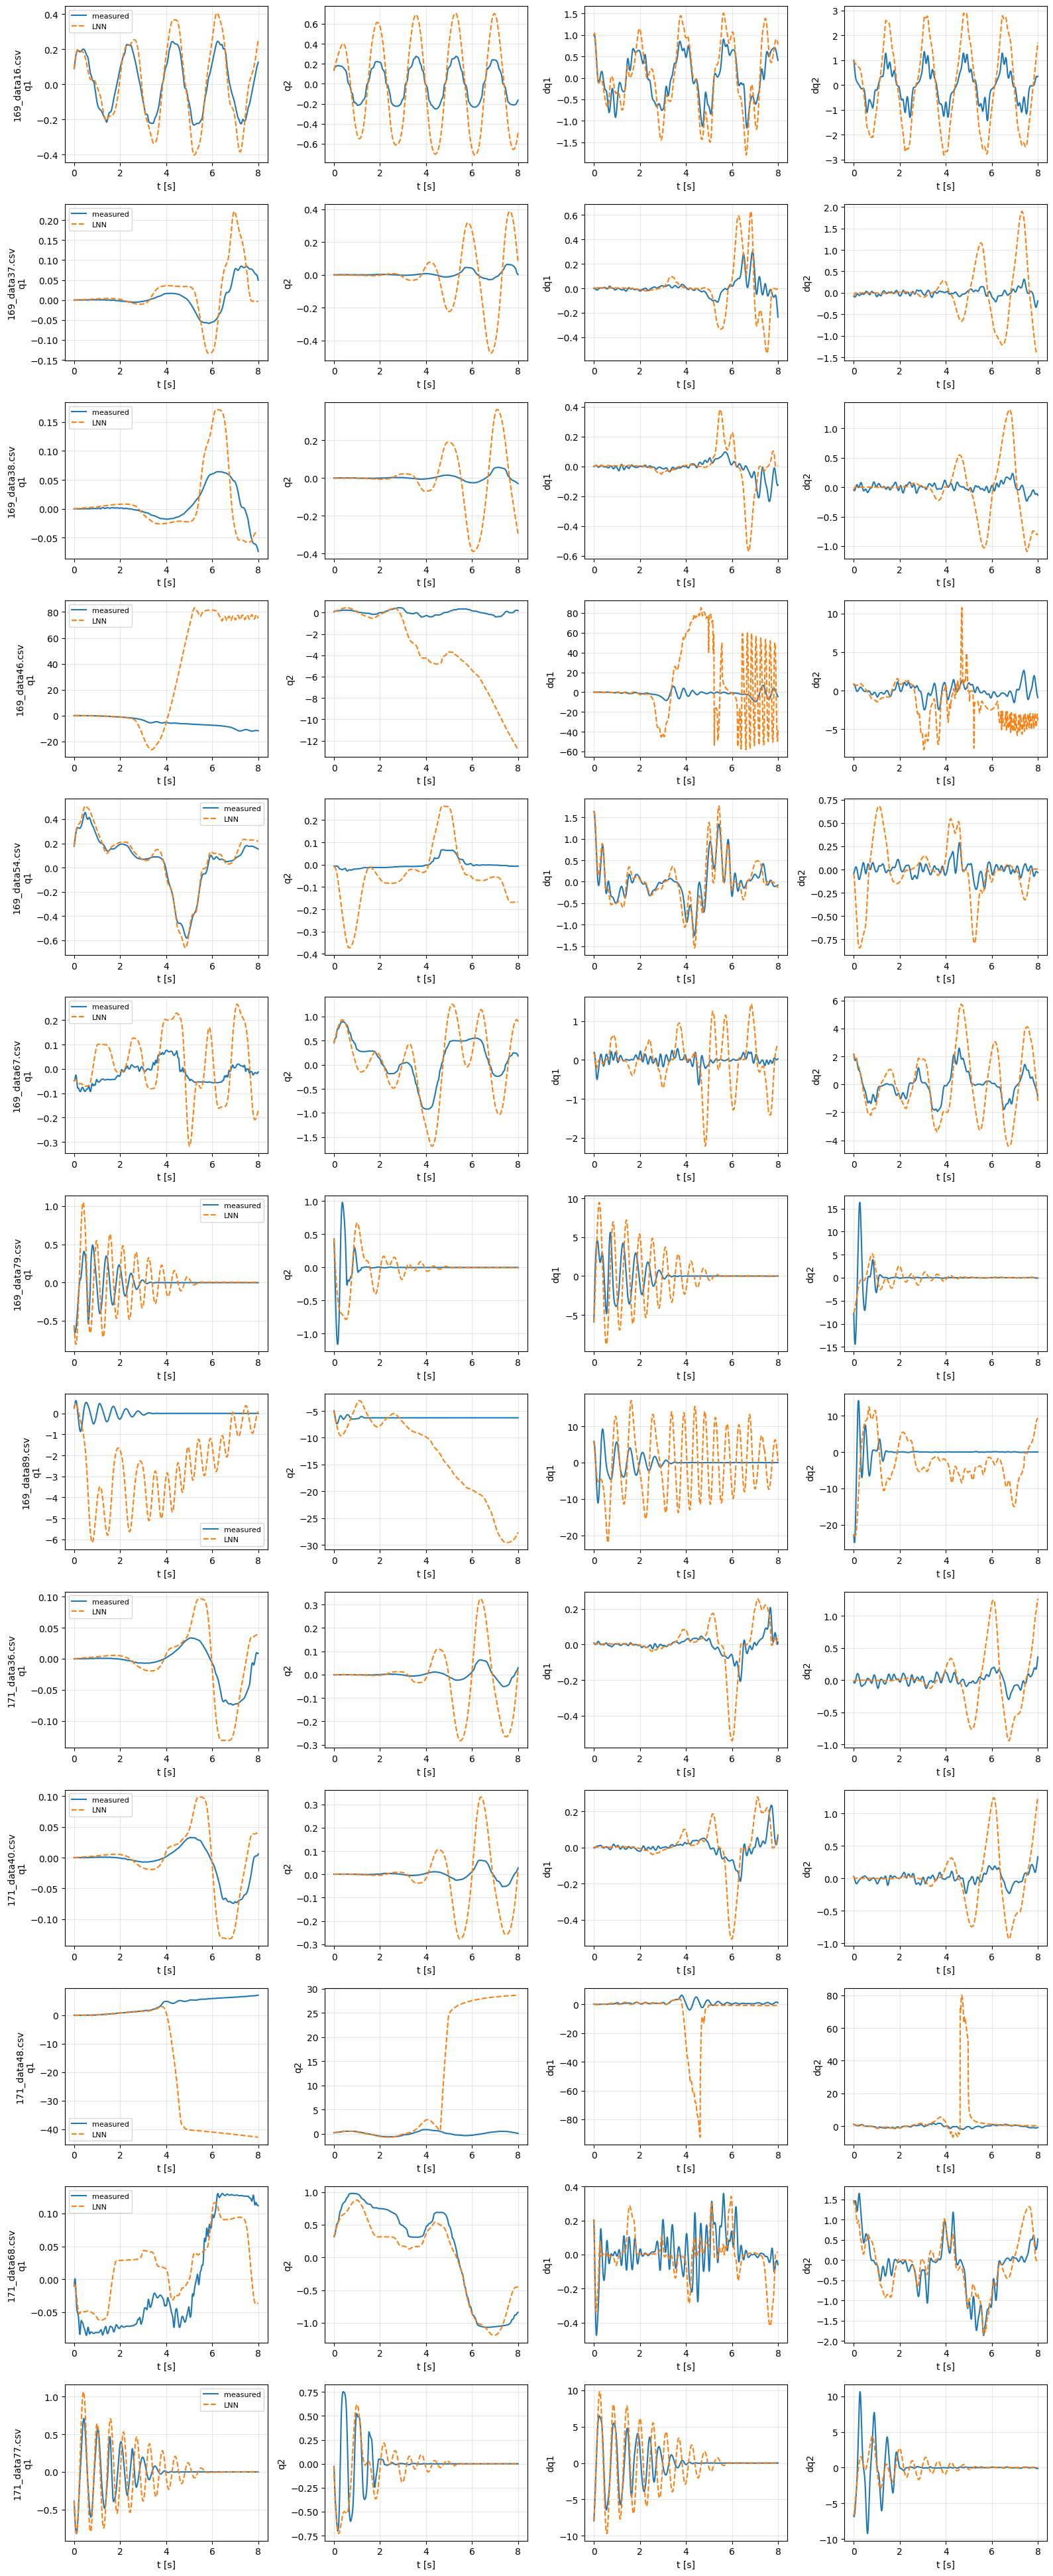

In [7]:
fig, axes = plt.subplots(len(results), 4, figsize=(16, 3*len(results)), squeeze=False)
for i, r in enumerate(results):
    name = os.path.basename(r['path'])
    for j, lbl in enumerate(['q1','q2','dq1','dq2']):
        axes[i,j].plot(r['t_pred'], r['X_meas'][:,j], lw=1.5, label='measured')
        axes[i,j].plot(r['t_pred'], r['X_pred'][:,j], '--', lw=1.5, label='LNN')
        axes[i,j].set_ylabel(f'{lbl}'); axes[i,j].set_xlabel('t [s]')
        axes[i,j].grid(True, alpha=.3)
    axes[i,0].set_ylabel(f'{name[:20]}\nq1')
    axes[i,0].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [8]:
import numpy as np
from training_v2.evaluation import rollout, rollout_metrics

VPT_THRESHOLD = 0.087  # ≈ 5° in rad, Lutter & Peters 2023

vpts = []
for test_csv in test_p:
    df = pd.read_csv(test_csv)
    t_meas = df['time'].to_numpy()
    X_meas = df[['pos1','pos2','vel1','vel2']].to_numpy()
    tau    = df[['tau1','tau2']].to_numpy()
    dt = float(t_meas[1] - t_meas[0])

    # Rollout the full trajectory
    t_pred, X_pred = rollout(model, X_meas[0], dt, tau, integrator='rk4')

    # Compute MSE at every timestep
    n = min(len(t_pred), len(X_meas))
    pos_mse = np.mean((X_pred[:n, :2] - X_meas[:n, :2])**2, axis=1)

    # VPT = first time MSE exceeds 1e-2
    over = np.where(pos_mse > 1e-2)[0]
    vpt_this = float(t_pred[over[0]]) if len(over) else float(t_pred[n-1])
    vpts.append(vpt_this)

vpts = np.asarray(vpts)
print(f'Median VPT: {np.median(vpts):.2f}s')
print(f'Mean VPT:   {np.mean(vpts):.2f}s ± {np.std(vpts):.2f}s')
print(f'Range:      [{vpts.min():.2f}s, {vpts.max():.2f}s]')

Median VPT: 0.34s
Mean VPT:   1.92s ± 2.16s
Range:      [0.03s, 5.19s]


## Test 3 — Energy along a rollout

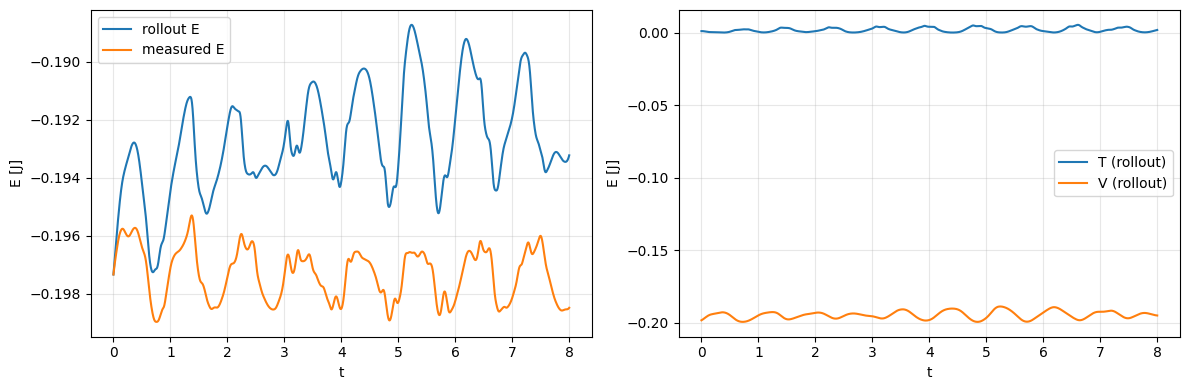

In [9]:
r = results[0]
E_pred, T_pred, V_pred = total_energy(model, r['X_pred'])
E_meas, _, _ = total_energy(model, r['X_meas'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(r['t_pred'], E_pred, label='rollout E'); axes[0].plot(r['t_pred'], E_meas, label='measured E')
axes[0].set_xlabel('t'); axes[0].set_ylabel('E [J]'); axes[0].legend(); axes[0].grid(True, alpha=.3)
axes[1].plot(r['t_pred'], T_pred, label='T (rollout)'); axes[1].plot(r['t_pred'], V_pred, label='V (rollout)')
axes[1].set_xlabel('t'); axes[1].set_ylabel('E [J]'); axes[1].legend(); axes[1].grid(True, alpha=.3)
plt.tight_layout(); plt.show()

## Test 4 — What the network learned

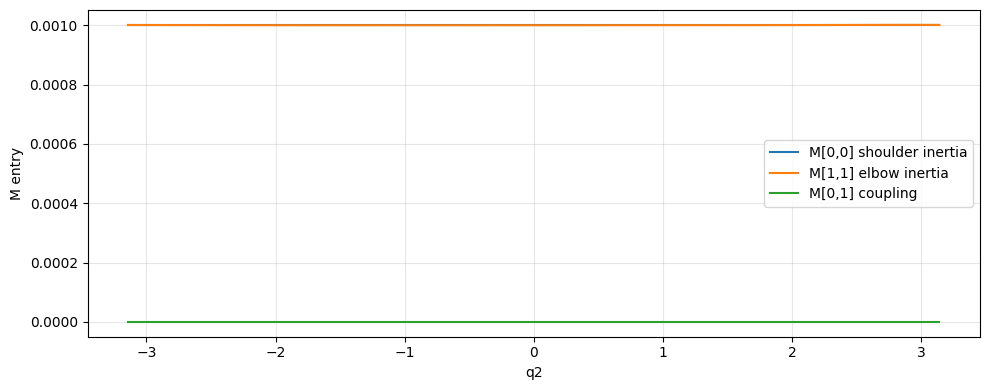

In [10]:
q2 = torch.linspace(-np.pi, np.pi, 200).unsqueeze(-1)
q  = torch.cat([torch.zeros_like(q2), q2], 1).to(device)
with torch.no_grad():
    M = model.mass_matrix(q).cpu().numpy()
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(q2.numpy(), M[:,0,0], label='M[0,0] shoulder inertia')
ax.plot(q2.numpy(), M[:,1,1], label='M[1,1] elbow inertia')
ax.plot(q2.numpy(), M[:,0,1], label='M[0,1] coupling')
ax.set_xlabel('q2'); ax.set_ylabel('M entry'); ax.legend(); ax.grid(True, alpha=.3); plt.tight_layout(); plt.show()

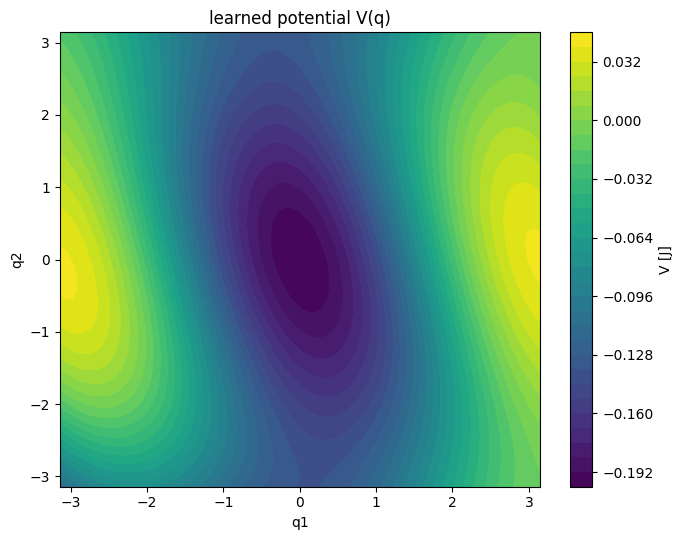

In [11]:
Q1g = torch.linspace(-np.pi, np.pi, 80); Q2g = torch.linspace(-np.pi, np.pi, 80)
Q1, Q2 = torch.meshgrid(Q1g, Q2g, indexing='ij')
qq = torch.stack([Q1.flatten(), Q2.flatten()], 1).to(device)
with torch.no_grad(): V = model.potential(qq).cpu().numpy().reshape(80, 80)
fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.contourf(Q1.numpy(), Q2.numpy(), V, levels=30, cmap='viridis')
plt.colorbar(im, label='V [J]'); ax.set_xlabel('q1'); ax.set_ylabel('q2'); ax.set_title('learned potential V(q)')
plt.tight_layout(); plt.show()

  shoulder  b=0.00000  c=0.00143
  elbow     b=0.00129  c=0.00095


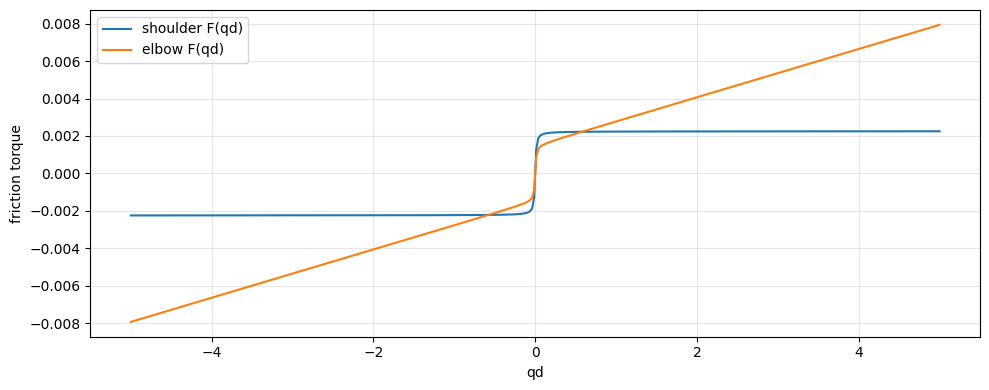

In [12]:
if model.learn_friction:
    b = torch.exp(model.log_b_friction).detach().cpu().numpy()
    c = torch.exp(model.log_c_friction).detach().cpu().numpy()
    print(f'  shoulder  b={b[0]:.5f}  c={c[0]:.5f}')
    print(f'  elbow     b={b[1]:.5f}  c={c[1]:.5f}')
    qd = np.linspace(-5, 5, 400)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(qd, b[0]*qd + c[0]*np.arctan(100*qd), label='shoulder F(qd)')
    ax.plot(qd, b[1]*qd + c[1]*np.arctan(100*qd), label='elbow F(qd)')
    ax.set_xlabel('qd'); ax.set_ylabel('friction torque'); ax.legend(); ax.grid(True, alpha=.3); plt.tight_layout(); plt.show()

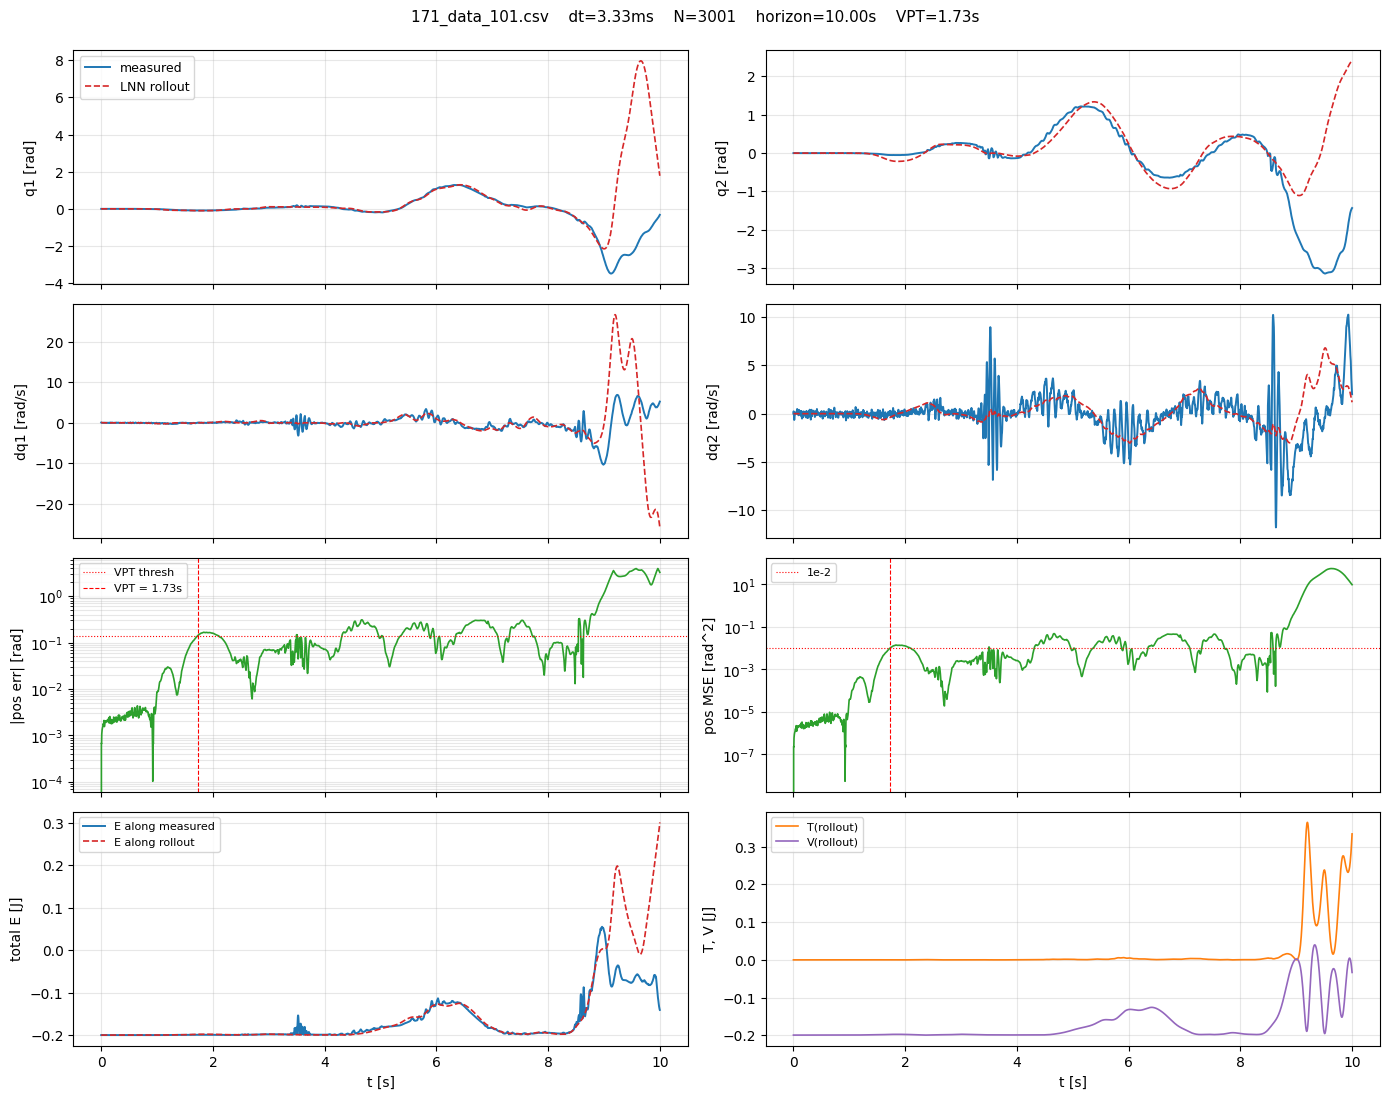


171_data_101.csv:
  dt:               3.333 ms
  rollout horizon:  10.00 s (3001 steps)
  VPT (MSE<0.01): 1.73 s
  RMSE pos @ 0.5s:  0.0000 rad
  RMSE pos @ 1.0s:  0.0000 rad
  RMSE pos @ 2.0s:  0.0051 rad
  energy drift:     5.0018e-01 J  (rel: 250.80%)


In [13]:
from training_v2.model import DeepLagrangianNetwork_f1, DeepLagrangianNetwork_f2, DeepLagrangianNetwork_f3
from singlecsvcomp import compare_csv_to_model
model = DeepLagrangianNetwork_f1(n_dof=2, learn_friction=True,
                              n_width=64, n_depth=2, activation='Sine',
                              diagonal_epsilon=1e-3, b_diag_init=0.5)

# model = DeepLagrangianNetwork_f3(
#     n_dof=2,
#     learn_friction=True,
#     n_width=64, n_depth=2, activation='SoftPlus',
#     diagonal_epsilon=1e-3, b_diag_init=0.5,
#     friction_hidden=32,
#     friction_depth=2,
#     friction_input_scale=10.0,         # tune to typical |qd| in your data
#     friction_output_scale_init=0.01,   # start friction small
# )


ck = torch.load(os.path.join(CKPT_DIR, 'delan_best91_sine_f1_1.pt'), map_location=device, weights_only=False)
model.load_state_dict(ck['model']); model.eval()

csv= '../filtered_test/171_data_101.csv'
result = compare_csv_to_model(csv, model,
                              rollout_horizon=10.0)

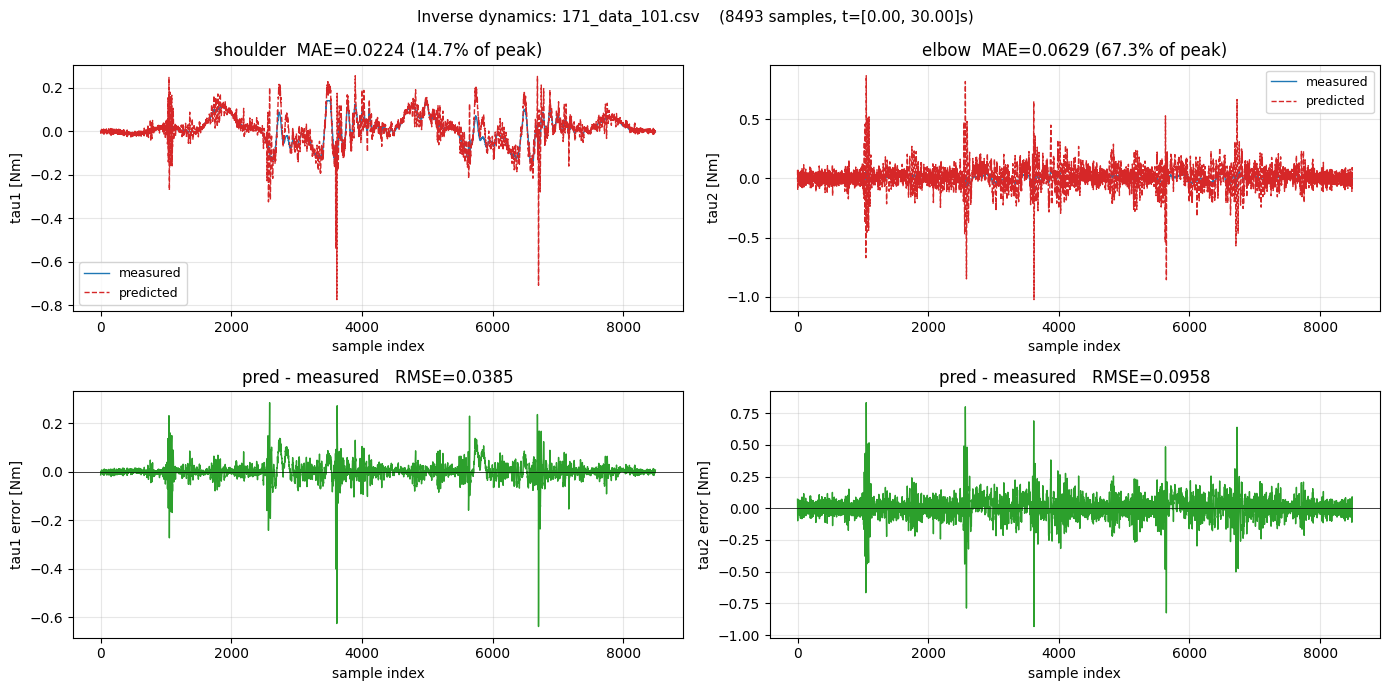

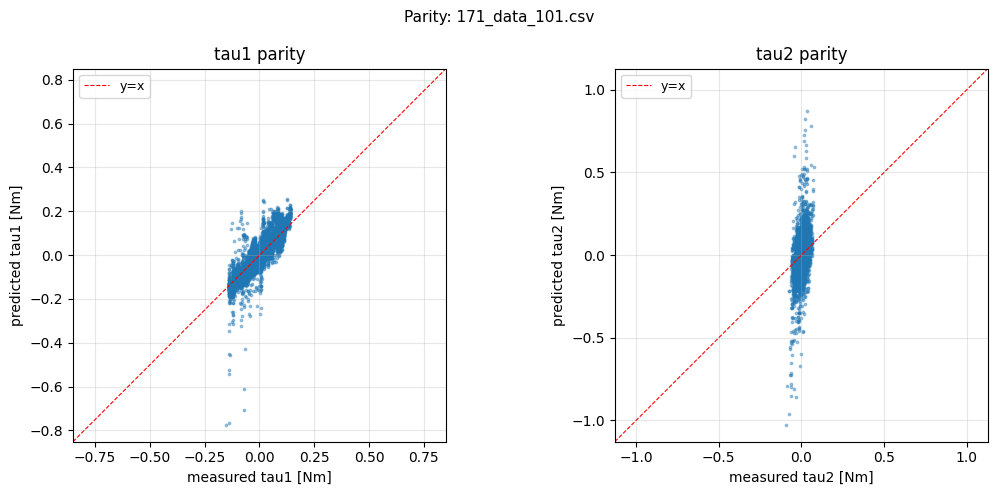


171_data_101.csv
  samples:    8493
  time range: [0.00, 30.00] s  (duration 30.00s)
  median dt:  3.33 ms
  tau1 MAE:   0.02242 Nm  (14.75% of peak 0.1520)
  tau2 MAE:   0.06292 Nm  (67.34% of peak 0.0934)


In [14]:
from singlecsvcomp import plot_inverse_dynamics
result = plot_inverse_dynamics(csv, model)